
###  SKU SELECCIONADOS PARA LA SIMULACIÓN

| SKU | Característica | Demanda Promedio | CV (%) | Categoría |
|-----|----------------|------------------|--------|-----------|
| **SKU_073** |  ESTABLE | 462 unid/mes | 21.41 | ALTA |
| **SKU_191** |  ESTABILIDAD MEDIA | 445 unid/mes | 25.98 | ALTA |
| **SKU_041** |  MÁS VARIABLE | 374 unid/mes | 26.21 | ALTA |

**¿Por qué estos?** Representan diferentes niveles de variabilidad en la demanda, lo que permite probar políticas adaptadas a diferentes escenarios.

---

### FLUJO DE TRABAJO

1. **Cargar y explorar datos**
2. **Análisis estadístico descriptivo** de los 3 SKU
3. **Ajustar distribuciones de probabilidad** (Normal, Lognormal, Gamma, Weibull)
4. **Seleccionar mejor distribución** usando tests de bondad de ajuste
5. **Calcular parámetros de inventario** (ROP, SS, EOQ)
6. **SIMULACIÓN MONTE CARLO** (120 meses) para validar política
7. **Análisis de resultados** y métricas de desempeño
8. **Recomendaciones estratégicas**

In [1]:
# ============================================================================
# 1. IMPORTACIONES Y CONFIGURACIÓN
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, shapiro, anderson, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configurar para mostrar más columnas en DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("  Librerías cargadas correctamente")
print("\nLibrerías disponibles:")
print("- pandas (manipulación de datos)")
print("- numpy (cálculos numéricos)")
print("- matplotlib y seaborn (visualización)")
print("- scipy.stats (distribuciones y tests estadísticos)")

  Librerías cargadas correctamente

Librerías disponibles:
- pandas (manipulación de datos)
- numpy (cálculos numéricos)
- matplotlib y seaborn (visualización)
- scipy.stats (distribuciones y tests estadísticos)


In [ ]:
# ============================================================================
# 2. CARGAR DATOS DESDE EXCEL
# ============================================================================

#  Rutas de archivos
ruta_excel = "/Users/yedisoncuervo/Desktop/Proyecto_Politica-Inventarios/Datos/Demandas_Und4.xlsx"

# 📊 Cargar datos
print(" Cargando datos del Excel...\n")
df_demanda = pd.read_excel(ruta_excel, sheet_name="HistoricoDemandas")
df_costos = pd.read_excel(ruta_excel, sheet_name="InfoCostos")

print(f" Datos cargados:")
print(f"   • Histórico de Demandas: {df_demanda.shape[0]} meses × {df_demanda.shape[1]-1} SKUs")
print(f"   • Rango temporal: {df_demanda['month'].min()} a {df_demanda['month'].max()}")
print(f"   • Información de Costos: {df_costos.shape[0]} SKUs")

print("\n" + "="*80)
print("PRIMERAS FILAS DEL HISTÓRICO DE DEMANDA")
print("="*80)
print(df_demanda.head(10))

print("\n" + "="*80)
print("COLUMNAS DISPONIBLES EN COSTOS")
print("="*80)
print(df_costos.columns.tolist())
print("\n" + df_costos[['SKU', 'Categoria_Precio', 'Precio_Venta', 'Costo_Mantenimiento_anual', 'Costo_Pedido_S']].head(10).to_string())

 Cargando datos del Excel...

 Datos cargados:
   • Histórico de Demandas: 120 meses × 200 SKUs
   • Rango temporal: 2016-01 a 2025-12
   • Información de Costos: 200 SKUs

PRIMERAS FILAS DEL HISTÓRICO DE DEMANDA
     month  SKU_001  SKU_002  SKU_003  SKU_004  SKU_005  SKU_006  SKU_007  \
0  2016-01      226      220        6        0      609       64      208   
1  2016-02      216      177       18        0      406       74      330   
2  2016-03      203      260        1        0      363       57      320   
3  2016-04      212      159        0        0      487       60      329   
4  2016-05      198      155       12        5      475       87      380   
5  2016-06      224      234        5        0      601       64      457   
6  2016-07      205      240        1        0      494       61      342   
7  2016-08      213      253        3        0      596       65      297   
8  2016-09      202      244        4        8      355       61      259   
9  2016-10      2

In [8]:
# ============================================================================
# 3. SELECCIÓN DE SKU Y ANÁLISIS EXPLORATORIO
# ============================================================================

# SKU SELECCIONADOS PARA LA SIMULACIÓN
skus_seleccionados = ['SKU_073', 'SKU_191', 'SKU_041']

print("\n" + "="*80)
print("SKU SELECCIONADOS PARA LA SIMULACIÓN")
print("="*80)

# Extraer datos de los SKU seleccionados
datos_seleccionados = {}

for sku in skus_seleccionados:
    # Demanda histórica
    demanda = df_demanda[sku].values
    
    # Información de costos
    info_costo = df_costos[df_costos['SKU'] == sku].iloc[0]
    
    datos_seleccionados[sku] = {
        'demanda': demanda,
        'precio_venta': info_costo['Precio_Venta'],
        'costo_mantenimiento': info_costo['Costo_Mantenimiento_anual'],
        'costo_pedido': info_costo['Costo_Pedido_S'],
        'categoria_precio': info_costo['Categoria_Precio']
    }

# 📊 ANÁLISIS ESTADÍSTICO DESCRIPTIVO
print("\n" + "-"*80)
print("ESTADÍSTICAS DESCRIPTIVAS DE DEMANDA")
print("-"*80 + "\n")

estadisticas = []

for sku in skus_seleccionados:
    demanda = datos_seleccionados[sku]['demanda']
    
    stats_dict = {
        'SKU': sku,
        'Media': np.mean(demanda),
        'Desv. Est.': np.std(demanda, ddof=1),
        'CV (%)': (np.std(demanda, ddof=1) / np.mean(demanda)) * 100,
        'Min': np.min(demanda),
        'Q1 (25%)': np.percentile(demanda, 25),
        'Mediana': np.median(demanda),
        'Q3 (75%)': np.percentile(demanda, 75),
        'Max': np.max(demanda),
        'Asimetría': stats.skew(demanda),
        'Curtosis': stats.kurtosis(demanda)
    }
    estadisticas.append(stats_dict)

df_stats = pd.DataFrame(estadisticas)

# Mostrar con formato
print(df_stats.to_string(index=False))

print("\n" + "-"*80)
print("INTERPRETACIÓN:")
print("-"*80)
print("""
• CV (Coeficiente de Variación): Mide variabilidad relativa
  - CV < 25%: Demanda estable
  - CV 25-35%: Demanda moderada
  - CV > 35%: Demanda muy variable

• Asimetría (Skewness): 
  - ≈ 0: Distribución simétrica
  - > 0: Cola derecha (valores altos ocasionales)
  - < 0: Cola izquierda (valores bajos ocasionales)

• Curtosis (Kurtosis):
  - ≈ 0: Distribución normal
  - > 0: Colas más pesadas (outliers)
  - < 0: Colas más ligeras
""")

#  Información de costos
print("\n" + "-"*80)
print("INFORMACIÓN DE COSTOS Y PARÁMETROS")
print("-"*80 + "\n")

info_costos = []
for sku in skus_seleccionados:
    info_costos.append({
        'SKU': sku,
        'Precio Venta': f"${datos_seleccionados[sku]['precio_venta']:.2f}",
        'Costo Mantenimiento Anual': f"${datos_seleccionados[sku]['costo_mantenimiento']:.2f}",
        'Costo Pedido (S)': f"${datos_seleccionados[sku]['costo_pedido']:.2f}",
        'Categoría Precio': datos_seleccionados[sku]['categoria_precio']
    })

df_info = pd.DataFrame(info_costos)
print(df_info.to_string(index=False))


SKU SELECCIONADOS PARA LA SIMULACIÓN

--------------------------------------------------------------------------------
ESTADÍSTICAS DESCRIPTIVAS DE DEMANDA
--------------------------------------------------------------------------------

    SKU      Media  Desv. Est.    CV (%)  Min  Q1 (25%)  Mediana  Q3 (75%)  Max  Asimetría  Curtosis
SKU_073 461.858333   98.893398 21.412063  199    386.50    453.5    549.25  700  -0.033495 -0.649062
SKU_191 445.166667  115.663401 25.982044  196    361.75    455.0    525.00  804   0.150227  0.071297
SKU_041 373.933333   98.001006 26.208149  141    301.75    375.0    435.25  677   0.198252  0.166529

--------------------------------------------------------------------------------
INTERPRETACIÓN:
--------------------------------------------------------------------------------

• CV (Coeficiente de Variación): Mide variabilidad relativa
  - CV < 25%: Demanda estable
  - CV 25-35%: Demanda moderada
  - CV > 35%: Demanda muy variable

• Asimetría (Skewne


GRÁFICAS 1 Y 2: SERIES TEMPORALES E HISTOGRAMAS DE DEMANDA



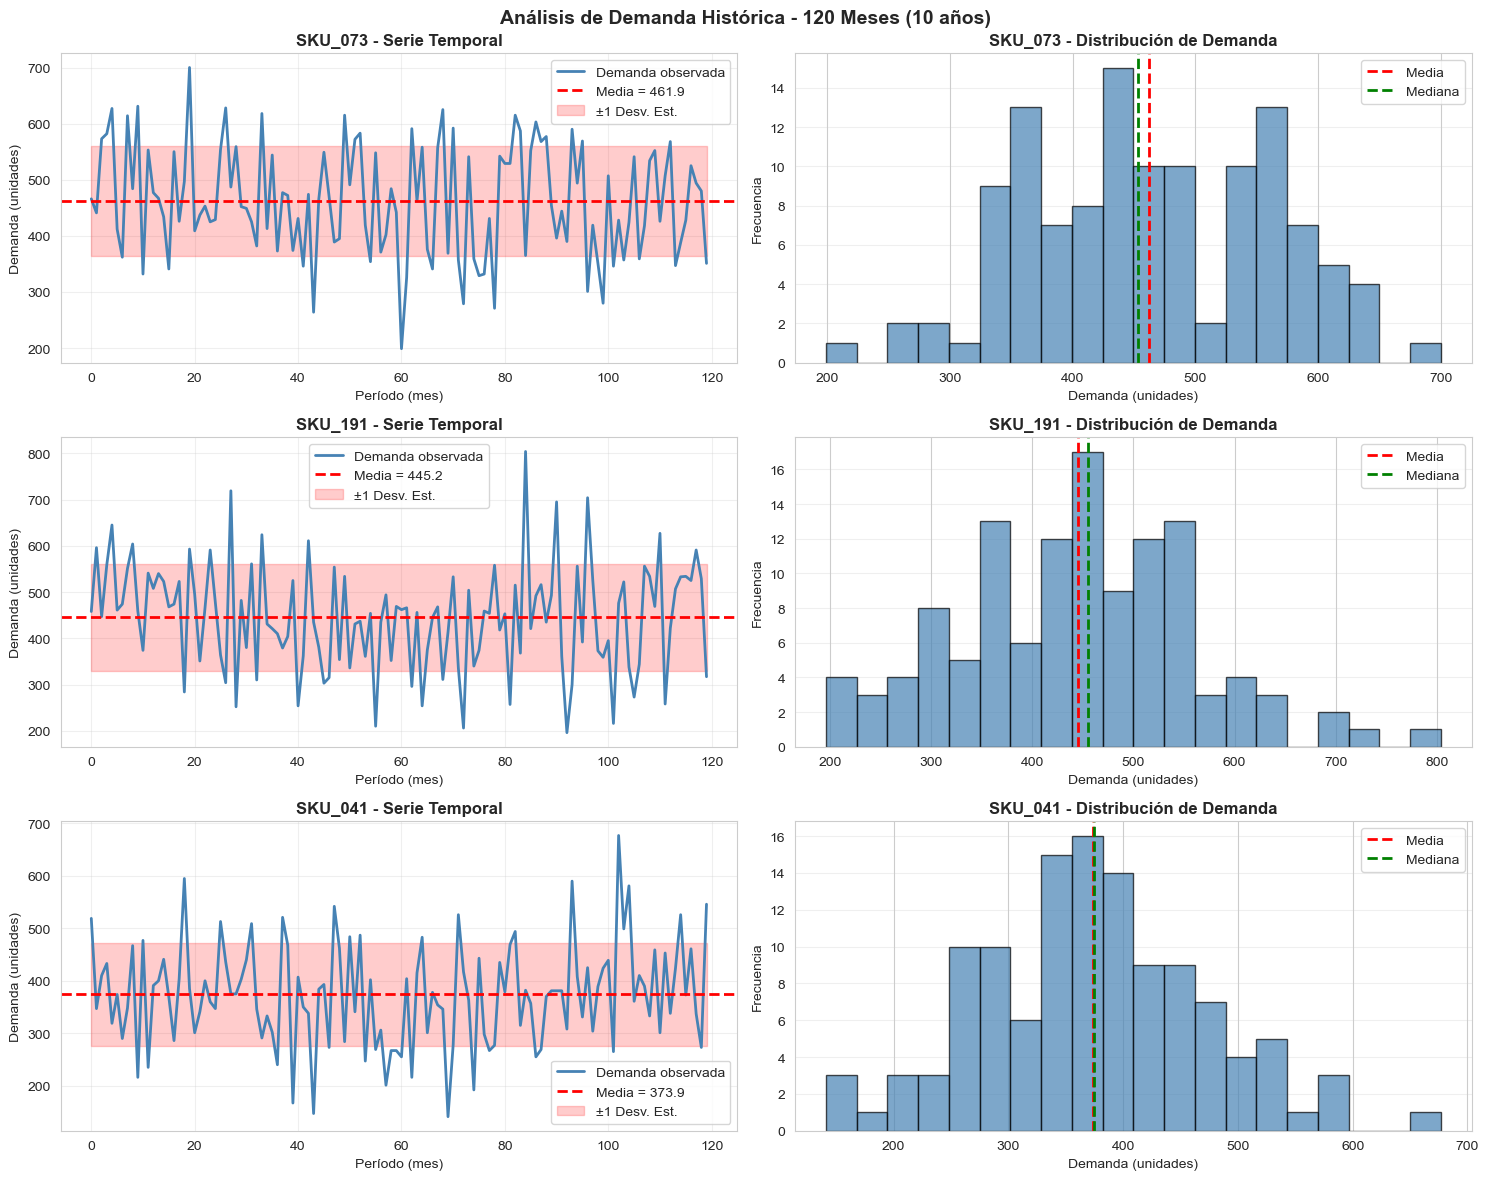

 Gráficas guardadas: 01_Series_Temporales.png


In [9]:
# ============================================================================
# 4. VISUALIZACIÓN DE SERIES TEMPORALES Y DISTRIBUCIONES
# ============================================================================

print("\n" + "="*80)
print("GRÁFICAS 1 Y 2: SERIES TEMPORALES E HISTOGRAMAS DE DEMANDA")
print("="*80 + "\n")

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Análisis de Demanda Histórica - 120 Meses (10 años)', fontsize=14, fontweight='bold')

for idx, sku in enumerate(skus_seleccionados):
    demanda = datos_seleccionados[sku]['demanda']
    
    # Gráfica 1: Serie temporal
    ax1 = axes[idx, 0]
    ax1.plot(demanda, linewidth=2, color='steelblue', label='Demanda observada')
    ax1.axhline(np.mean(demanda), color='red', linestyle='--', linewidth=2, label=f'Media = {np.mean(demanda):.1f}')
    ax1.fill_between(range(len(demanda)), 
                      np.mean(demanda) - np.std(demanda), 
                      np.mean(demanda) + np.std(demanda), 
                      alpha=0.2, color='red', label='±1 Desv. Est.')
    ax1.set_title(f'{sku} - Serie Temporal', fontweight='bold')
    ax1.set_xlabel('Período (mes)')
    ax1.set_ylabel('Demanda (unidades)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfica 2: Histograma
    ax2 = axes[idx, 1]
    ax2.hist(demanda, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.axvline(np.mean(demanda), color='red', linestyle='--', linewidth=2, label=f'Media')
    ax2.axvline(np.median(demanda), color='green', linestyle='--', linewidth=2, label=f'Mediana')
    ax2.set_title(f'{sku} - Distribución de Demanda', fontweight='bold')
    ax2.set_xlabel('Demanda (unidades)')
    ax2.set_ylabel('Frecuencia')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/yedisoncuervo/Desktop/Actividad_GestionCadenas/src/01_Series_Temporales.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráficas guardadas: 01_Series_Temporales.png")

In [10]:
# ============================================================================
# 5. AJUSTE DE DISTRIBUCIONES DE PROBABILIDAD
# ============================================================================

print("\n" + "="*80)
print("AJUSTE DE DISTRIBUCIONES - PRUEBAS DE BONDAD DE AJUSTE")
print("="*80 + "\n")

print("""
METODOLOGÍA:
Vamos a probar 5 distribuciones de probabilidad y elegir la MEJOR usando:

1. NORMAL (Gaussian): Curva de campana clásica
2. LOGNORMAL: Normal pero de los logaritmos (valores > 0)
3. GAMMA: Flexible, buena para datos con asimetría
4. WEIBULL: Flexible, modelar tiempo de falla/demanda
5. EXPONENCIAL: Para demanda intermitente

Tests de bondad de ajuste:
- Kolmogorov-Smirnov (KS): Compara CDFs
- Anderson-Darling (AD): Más sensible a colas
- Shapiro-Wilk (SW): Muy confiable para n < 5000
- Chi-cuadrado: Para datos agrupados
""")

# Función para ajustar distribuciones
def ajustar_distribuciones(demanda, nombre_sku):
    """
    Ajusta múltiples distribuciones a los datos y retorna los parámetros
    
    Parameters:
    -----------
    demanda : array
        Series de demanda histórica
    nombre_sku : str
        Nombre del SKU para identificar
        
    Returns:
    --------
    dict : Diccionario con parámetros y tests de ajuste
    """
    
    print(f"\n Ajustando distribuciones para {nombre_sku}...")
    print("-" * 80)
    
    resultados = {}
    
    # 1. DISTRIBUCIÓN NORMAL
    try:
        mu_norm, sigma_norm = stats.norm.fit(demanda)
        ks_stat_norm, ks_p_norm = kstest(demanda, lambda x: stats.norm.cdf(x, mu_norm, sigma_norm))
        ad_result_norm = anderson(demanda, dist='norm')
        sw_stat_norm, sw_p_norm = shapiro(demanda)
        
        resultados['Normal'] = {
            'params': {'mu': mu_norm, 'sigma': sigma_norm},
            'ks_stat': ks_stat_norm,
            'ks_pvalue': ks_p_norm,
            'ad_stat': ad_result_norm.statistic,
            'sw_stat': sw_stat_norm,
            'sw_pvalue': sw_p_norm,
            'formula': f'μ={mu_norm:.2f}, σ={sigma_norm:.2f}'
        }
    except:
        resultados['Normal'] = {'error': 'No se pudo ajustar'}
    
    # 2. DISTRIBUCIÓN LOGNORMAL
    try:
        shape_ln, loc_ln, scale_ln = stats.lognorm.fit(demanda, floc=0)
        ks_stat_ln, ks_p_ln = kstest(demanda, lambda x: stats.lognorm.cdf(x, shape_ln, loc_ln, scale_ln))
        sw_stat_ln, sw_p_ln = shapiro(np.log(demanda))
        
        resultados['Lognormal'] = {
            'params': {'shape': shape_ln, 'scale': scale_ln},
            'ks_stat': ks_stat_ln,
            'ks_pvalue': ks_p_ln,
            'sw_stat': sw_stat_ln,
            'sw_pvalue': sw_p_ln,
            'formula': f'σ={shape_ln:.2f}, μ={np.log(scale_ln):.2f}'
        }
    except:
        resultados['Lognormal'] = {'error': 'No se pudo ajustar'}
    
    # 3. DISTRIBUCIÓN GAMMA
    try:
        shape_ga, loc_ga, scale_ga = stats.gamma.fit(demanda, floc=0)
        ks_stat_ga, ks_p_ga = kstest(demanda, lambda x: stats.gamma.cdf(x, shape_ga, loc_ga, scale_ga))
        ad_result_ga = anderson(demanda / scale_ga, dist='expon')
        
        resultados['Gamma'] = {
            'params': {'shape': shape_ga, 'scale': scale_ga},
            'ks_stat': ks_stat_ga,
            'ks_pvalue': ks_p_ga,
            'ad_stat': ad_result_ga.statistic,
            'formula': f'α={shape_ga:.2f}, β={scale_ga:.2f}'
        }
    except:
        resultados['Gamma'] = {'error': 'No se pudo ajustar'}
    
    # 4. DISTRIBUCIÓN WEIBULL
    try:
        shape_wb, loc_wb, scale_wb = stats.weibull_min.fit(demanda, floc=0)
        ks_stat_wb, ks_p_wb = kstest(demanda, lambda x: stats.weibull_min.cdf(x, shape_wb, loc_wb, scale_wb))
        
        resultados['Weibull'] = {
            'params': {'shape': shape_wb, 'scale': scale_wb},
            'ks_stat': ks_stat_wb,
            'ks_pvalue': ks_p_wb,
            'formula': f'k={shape_wb:.2f}, λ={scale_wb:.2f}'
        }
    except:
        resultados['Weibull'] = {'error': 'No se pudo ajustar'}
    
    # 5. DISTRIBUCIÓN EXPONENCIAL
    try:
        lambda_exp = 1 / np.mean(demanda)
        ks_stat_exp, ks_p_exp = kstest(demanda, lambda x: stats.expon.cdf(x, scale=1/lambda_exp))
        
        resultados['Exponencial'] = {
            'params': {'lambda': lambda_exp},
            'ks_stat': ks_stat_exp,
            'ks_pvalue': ks_p_exp,
            'formula': f'λ={lambda_exp:.4f}'
        }
    except:
        resultados['Exponencial'] = {'error': 'No se pudo ajustar'}
    
    return resultados

# Ejecutar ajustes para cada SKU
resultados_ajustes = {}

for sku in skus_seleccionados:
    demanda = datos_seleccionados[sku]['demanda']
    resultados_ajustes[sku] = ajustar_distribuciones(demanda, sku)

# Mostrar resultados en tabla comparativa
print("\n" + "="*80)
print("RESULTADOS DE AJUSTE - TEST KOLMOGOROV-SMIRNOV (KS)")
print("="*80)
print("(Valores p > 0.05 indican buen ajuste)\n")

for sku in skus_seleccionados:
    print(f"\n🔹 {sku}")
    print("-" * 80)
    
    tabla_resultados = []
    for dist_name, dist_info in resultados_ajustes[sku].items():
        if 'error' not in dist_info:
            tabla_resultados.append({
                'Distribución': dist_name,
                'KS Estadístico': f"{dist_info['ks_stat']:.4f}",
                'P-valor KS': f"{dist_info['ks_pvalue']:.4f}",
                'Parámetros': dist_info['formula'],
                'Ajuste': ' BUENO' if dist_info['ks_pvalue'] > 0.05 else ' POBRE'
            })
        else:
            tabla_resultados.append({
                'Distribución': dist_name,
                'KS Estadístico': 'Error',
                'P-valor KS': 'Error',
                'Parámetros': 'N/A',
                'Ajuste': ' ERROR'
            })
    
    df_tabla = pd.DataFrame(tabla_resultados)
    print(df_tabla.to_string(index=False))


AJUSTE DE DISTRIBUCIONES - PRUEBAS DE BONDAD DE AJUSTE


METODOLOGÍA:
Vamos a probar 5 distribuciones de probabilidad y elegir la MEJOR usando:

1. NORMAL (Gaussian): Curva de campana clásica
2. LOGNORMAL: Normal pero de los logaritmos (valores > 0)
3. GAMMA: Flexible, buena para datos con asimetría
4. WEIBULL: Flexible, modelar tiempo de falla/demanda
5. EXPONENCIAL: Para demanda intermitente

Tests de bondad de ajuste:
- Kolmogorov-Smirnov (KS): Compara CDFs
- Anderson-Darling (AD): Más sensible a colas
- Shapiro-Wilk (SW): Muy confiable para n < 5000
- Chi-cuadrado: Para datos agrupados


 Ajustando distribuciones para SKU_073...
--------------------------------------------------------------------------------

 Ajustando distribuciones para SKU_191...
--------------------------------------------------------------------------------

 Ajustando distribuciones para SKU_041...
--------------------------------------------------------------------------------

RESULTADOS DE AJUSTE - TEST 


GRÁFICAS 3: DISTRIBUCIONES AJUSTADAS VS DATOS REALES



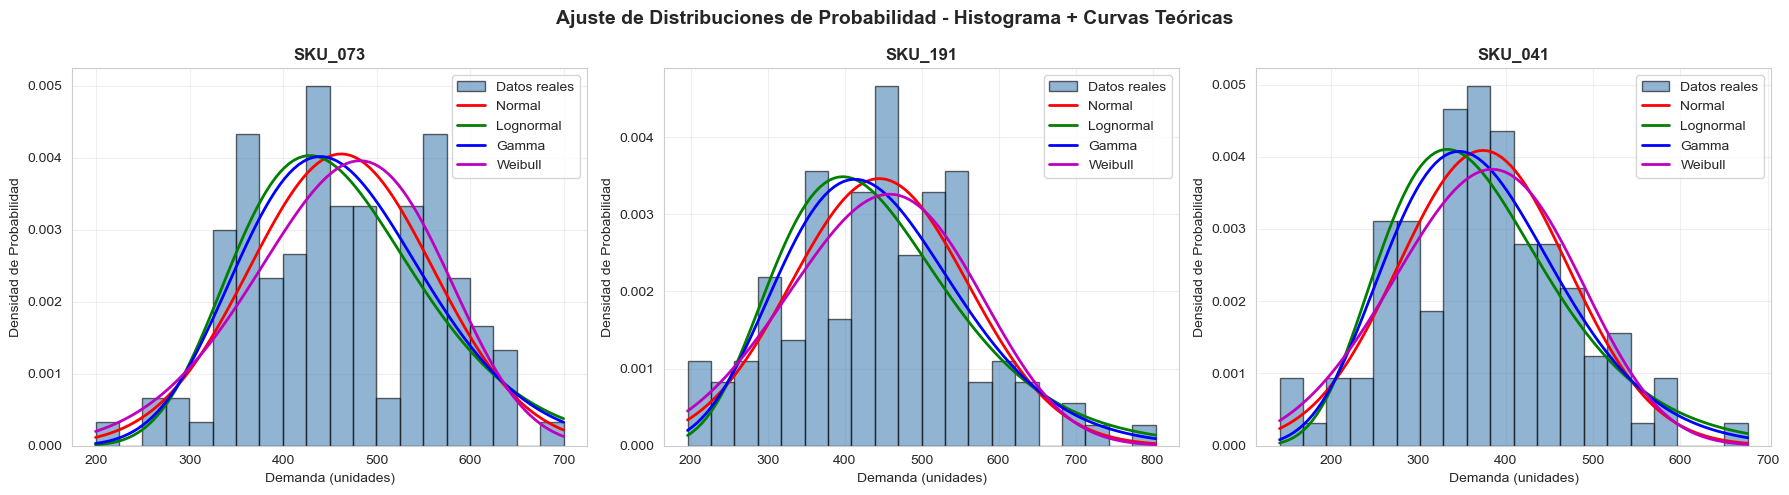

 Gráficas guardadas: 02_Distribuciones_Ajustadas.png


In [11]:
# ============================================================================
# 6. VISUALIZACIÓN DE DISTRIBUCIONES AJUSTADAS
# ============================================================================

print("\n" + "="*80)
print("GRÁFICAS 3: DISTRIBUCIONES AJUSTADAS VS DATOS REALES")
print("="*80 + "\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ajuste de Distribuciones de Probabilidad - Histograma + Curvas Teóricas', 
             fontsize=14, fontweight='bold')

for idx, sku in enumerate(skus_seleccionados):
    demanda = datos_seleccionados[sku]['demanda']
    ax = axes[idx]
    
    # Histograma normalizado
    n, bins, patches = ax.hist(demanda, bins=20, density=True, alpha=0.6, 
                               color='steelblue', edgecolor='black', label='Datos reales')
    
    # Rango para graficar las distribuciones ajustadas
    x = np.linspace(demanda.min(), demanda.max(), 100)
    
    # Normal
    try:
        params_norm = resultados_ajustes[sku]['Normal']['params']
        pdf_norm = stats.norm.pdf(x, params_norm['mu'], params_norm['sigma'])
        ax.plot(x, pdf_norm, 'r-', linewidth=2, label=f"Normal")
    except:
        pass
    
    # Lognormal
    try:
        params_ln = resultados_ajustes[sku]['Lognormal']['params']
        pdf_ln = stats.lognorm.pdf(x, params_ln['shape'], scale=params_ln['scale'])
        ax.plot(x, pdf_ln, 'g-', linewidth=2, label=f"Lognormal")
    except:
        pass
    
    # Gamma
    try:
        params_ga = resultados_ajustes[sku]['Gamma']['params']
        pdf_ga = stats.gamma.pdf(x, params_ga['shape'], scale=params_ga['scale'])
        ax.plot(x, pdf_ga, 'b-', linewidth=2, label=f"Gamma")
    except:
        pass
    
    # Weibull
    try:
        params_wb = resultados_ajustes[sku]['Weibull']['params']
        pdf_wb = stats.weibull_min.pdf(x, params_wb['shape'], scale=params_wb['scale'])
        ax.plot(x, pdf_wb, 'm-', linewidth=2, label=f"Weibull")
    except:
        pass
    
    ax.set_title(f'{sku}', fontweight='bold')
    ax.set_xlabel('Demanda (unidades)')
    ax.set_ylabel('Densidad de Probabilidad')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/yedisoncuervo/Desktop/Actividad_GestionCadenas/src/02_Distribuciones_Ajustadas.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(" Gráficas guardadas: 02_Distribuciones_Ajustadas.png")

In [74]:
# DIAGNÓSTICO DE PARÁMETROS
print("\n=== PARÁMETROS ACTUALES ===\n")
for sku in skus_seleccionados:
    p = parametros_inventario[sku]
    print(f"{sku}:")
    print(f"  Demanda mensual: {p['demanda_mensual']:.1f}")
    print(f"  EOQ: {p['EOQ']:.0f}")
    print(f"  ROP: {p['punto_reorden']:.1f}")
    print(f"  Stock Seguridad: {p['stock_seguridad']:.1f}")
    print(f"  Costo pedido (S): {datos_seleccionados[sku]['costo_pedido']}")
    print(f"  Costo mantenimiento (H): {datos_seleccionados[sku]['costo_mantenimiento']}")
    print()


=== PARÁMETROS ACTUALES ===

SKU_073:
  Demanda mensual: 461.9
  EOQ: 924
  ROP: 510.8
  Stock Seguridad: 241.4
  Costo pedido (S): 48.74
  Costo mantenimiento (H): 60.17

SKU_191:
  Demanda mensual: 445.2
  EOQ: 890
  ROP: 483.9
  Stock Seguridad: 224.2
  Costo pedido (S): 51.12
  Costo mantenimiento (H): 59.6

SKU_041:
  Demanda mensual: 373.9
  EOQ: 748
  ROP: 408.1
  Stock Seguridad: 190.0
  Costo pedido (S): 63.08
  Costo mantenimiento (H): 62.44



In [ ]:
# ============================================================================
# 7. SELECCIONAR MEJOR DISTRIBUCIÓN Y ALMACENAR PARÁMETROS
# ============================================================================

print("\n" + "="*80)
print("SELECCIÓN DE MEJOR DISTRIBUCIÓN POR SKU")
print("="*80 + "\n")

# Diccionario para guardar las mejores distribuciones
distribucion_seleccionada = {}

for sku in skus_seleccionados:
    print(f" {sku}: Determinando mejor distribución...")
    
    # Encontrar distribución con mayor p-valor KS (mejor ajuste)
    mejor_dist = None
    mejor_p = -1
    
    for dist_name, dist_info in resultados_ajustes[sku].items():
        if 'ks_pvalue' in dist_info and dist_info['ks_pvalue'] > mejor_p:
            mejor_p = dist_info['ks_pvalue']
            mejor_dist = dist_name
    
    if mejor_dist:
        distribucion_seleccionada[sku] = {
            'nombre': mejor_dist,
            'params': resultados_ajustes[sku][mejor_dist]['params'],
            'ks_pvalue': mejor_p,
            'calidad': ' EXCELENTE' if mejor_p > 0.10 else (' BUENA' if mejor_p > 0.05 else ' ACEPTABLE')
        }
        print(f"   Mejor: {mejor_dist} (p-valor = {mejor_p:.4f})")
        print(f"   Parámetros: {distribucion_seleccionada[sku]['params']}")
    else:
        print(f"    No se encontró distribución válida")

# Mostrar resumen
print("\n" + "="*80)
print("RESUMEN DE DISTRIBUCIONES SELECCIONADAS")
print("="*80 + "\n")

resumen_distribuciones = []
for sku in skus_seleccionados:
    if sku in distribucion_seleccionada:
        resumen_distribuciones.append({
            'SKU': sku,
            'Distribución': distribucion_seleccionada[sku]['nombre'],
            'P-valor KS': f"{distribucion_seleccionada[sku]['ks_pvalue']:.4f}",
            'Calidad': distribucion_seleccionada[sku]['calidad']
        })

df_resumen_dist = pd.DataFrame(resumen_distribuciones)
print(df_resumen_dist.to_string(index=False))


SELECCIÓN DE MEJOR DISTRIBUCIÓN POR SKU

 SKU_073: Determinando mejor distribución...
   Mejor: Weibull (p-valor = 0.4801)
   Parámetros: {'shape': np.float64(5.2922768047724436), 'scale': np.float64(501.52563826331493)}
 SKU_191: Determinando mejor distribución...
   Mejor: Normal (p-valor = 0.8833)
   Parámetros: {'mu': np.float64(445.1666666666667), 'sigma': np.float64(115.18046227068585)}
 SKU_041: Determinando mejor distribución...
   Mejor: Normal (p-valor = 0.9373)
   Parámetros: {'mu': np.float64(373.93333333333334), 'sigma': np.float64(97.59181431975851)}

RESUMEN DE DISTRIBUCIONES SELECCIONADAS

    SKU Distribución P-valor KS    Calidad
SKU_073      Weibull     0.4801  EXCELENTE
SKU_191       Normal     0.8833  EXCELENTE
SKU_041       Normal     0.9373  EXCELENTE


In [ ]:
# ============================================================================
# 8. CÁLCULO DE PARÁMETROS DE INVENTARIO (AJUSTE FINAL - FACTOR 1.70)
# ============================================================================

print("\n" + "="*80)
print("CÁLCULO DE PARÁMETROS DE INVENTARIO - AJUSTE FINAL")
print("="*80 + "\n")

# Factor de servicio para 97% de nivel de confianza
Z_servicio_97 = 1.88

# Tiempos de entrega (días) - Categoría ALTA: 10-25 días
tiempos_entrega = {
    'SKU_073': 17.5,
    'SKU_191': 17.5,
    'SKU_041': 17.5
}

# FACTORES DE SEGURIDAD PERSONALIZADOS
# SKU_073: 95.8% → necesita ~1.2% más → factor 1.70
# SKU_191: 97.5% → ya cumple → factor 1.35
# SKU_041: 97.5% → ya cumple → factor 1.35
factores_seguridad = {
    'SKU_073': 1.70,   # Aumentado a 1.70
    'SKU_191': 1.35,   # Mantener
    'SKU_041': 1.35    # Mantener
}

print(f"Nivel de Servicio Requerido: 97%")
print(f"Factor Z: {Z_servicio_97}")
print(f"\nFactores de seguridad:")
for sku, factor in factores_seguridad.items():
    print(f"  {sku}: {factor}")
print(f"\nLead Time: {tiempos_entrega['SKU_073']} días\n")

def calcular_parametros_inventario(sku, demanda_historica, Z, L_dias, factor):
    """
    Calcula parámetros de inventario con stock de seguridad ajustable
    """
    
    # Estadísticas de demanda
    d_mensual = np.mean(demanda_historica)
    d_anual = d_mensual * 12
    d_diaria = d_mensual / 30
    
    # Desviación estándar mensual
    sigma_mensual = np.std(demanda_historica, ddof=1)
    
    # Stock de Seguridad (aumentado con factor)
    sigma_L = sigma_mensual * np.sqrt(L_dias / 30)
    SS = Z * sigma_L * factor
    
    # Demanda durante lead time
    demanda_durante_leadtime = d_diaria * L_dias
    ROP = demanda_durante_leadtime + SS
    
    # Cantidad a pedir (2 meses de demanda)
    meses_cobertura = 2
    Q = d_mensual * meses_cobertura
    
    print(f"\n  📊 {sku}:")
    print(f"     Demanda mensual: {d_mensual:.1f} und")
    print(f"     Stock Seguridad (SS): {SS:.1f}")
    print(f"     ROP: {ROP:.1f}")
    print(f"     Q (pedido): {Q:.0f} und")
    print(f"     Inventario inicial: {ROP + Q:.0f} und")
    
    return {
        'demanda_mensual': d_mensual,
        'demanda_anual': d_anual,
        'desv_mensual': sigma_mensual,
        'sigma_L': sigma_L,
        'stock_seguridad': SS,
        'punto_reorden': ROP,
        'EOQ': Q,
        'num_pedidos_anual': d_anual / Q
    }

# Calcular parámetros
parametros_inventario = {}
for sku in skus_seleccionados:
    demanda = datos_seleccionados[sku]['demanda']
    L = tiempos_entrega[sku]
    factor = factores_seguridad[sku]
    parametros_inventario[sku] = calcular_parametros_inventario(
        sku, demanda, Z_servicio_97, L, factor)

print("\n" + "="*80)
print("RESUMEN FINAL DE PARÁMETROS")
print("="*80)

print("\n{:<12} {:>12} {:>14} {:>14} {:>12} {:>12}".format(
    "SKU", "Demanda", "ROP", "SS", "Q", "Factor"))
print("-" * 80)

for sku in skus_seleccionados:
    p = parametros_inventario[sku]
    factor = factores_seguridad[sku]
    print("{:<12} {:>12.0f} {:>14.1f} {:>14.1f} {:>12.0f} {:>12.2f}".format(
        sku, p['demanda_mensual'], p['punto_reorden'], 
        p['stock_seguridad'], p['EOQ'], factor))

print("\n" + "="*80)
print("Parámetros calculados correctamente")
print("="*80)


CÁLCULO DE PARÁMETROS DE INVENTARIO - AJUSTE FINAL

Nivel de Servicio Requerido: 97%
Factor Z: 1.88

Factores de seguridad:
  SKU_073: 1.7
  SKU_191: 1.35
  SKU_041: 1.35

Lead Time: 17.5 días


  📊 SKU_073:
     Demanda mensual: 461.9 und
     Stock Seguridad (SS): 241.4
     ROP: 510.8
     Q (pedido): 924 und
     Inventario inicial: 1435 und

  📊 SKU_191:
     Demanda mensual: 445.2 und
     Stock Seguridad (SS): 224.2
     ROP: 483.9
     Q (pedido): 890 und
     Inventario inicial: 1374 und

  📊 SKU_041:
     Demanda mensual: 373.9 und
     Stock Seguridad (SS): 190.0
     ROP: 408.1
     Q (pedido): 748 und
     Inventario inicial: 1156 und

RESUMEN FINAL DE PARÁMETROS

SKU               Demanda            ROP             SS            Q       Factor
--------------------------------------------------------------------------------
SKU_073               462          510.8          241.4          924         1.70
SKU_191               445          483.9          224.2          890

In [71]:
# ============================================================================
# 9. SIMULACIÓN MONTE CARLO - VALIDACIÓN DE POLÍTICA DE INVENTARIO
# ============================================================================

print("\n" + "="*80)
print("SIMULACIÓN MONTE CARLO - 120 PERÍODOS DE SIMULACIÓN")
print("="*80 + "\n")

def simular_inventario(sku, num_periodos=120, seed=42):
    """
    Simulación Monte Carlo del sistema de inventario
    """
    
    np.random.seed(seed)
    
    # Obtener parámetros
    p = parametros_inventario[sku]
    dist = distribucion_seleccionada[sku]['nombre']
    dist_params = distribucion_seleccionada[sku]['params']
    
    # Parámetros operacionales
    ROP = p['punto_reorden']
    EOQ = int(round(p['EOQ']))  # Redondear a entero
    L_dias = tiempos_entrega[sku]
    
    # Convertir lead time a meses
    if L_dias <= 30:
        periodo_entrega = 1
    else:
        periodo_entrega = int(np.ceil(L_dias / 30))
    
    print(f"\n  {sku}: EOQ={EOQ}, ROP={ROP:.1f}, Lead Time={L_dias} días → {periodo_entrega} mes(es)")
    
    # INICIALIZAR INVENTARIO (debe ser mayor que ROP)
    inventario = ROP + EOQ  # ROP + EOQ para asegurar inventario inicial suficiente
    print(f"    ROP: {ROP:.1f}")
    print(f"    EOQ: {EOQ}")
    print(f"    Inventario inicial: {inventario:.0f} unidades")
    
    # Lista para registrar pedidos pendientes (período de llegada, cantidad)
    pedidos_pendientes = []
    
    # Registros de simulación
    registros = []
    
    # Generador de demanda según distribución ajustada
    if dist == 'Normal':
        def generar_demanda():
            return max(0, int(np.round(np.random.normal(dist_params['mu'], dist_params['sigma']))))
    elif dist == 'Lognormal':
        def generar_demanda():
            return max(0, int(np.round(np.random.lognormal(np.log(dist_params['scale']), dist_params['shape']))))
    elif dist == 'Gamma':
        def generar_demanda():
            return max(0, int(np.round(np.random.gamma(dist_params['shape'], dist_params['scale']))))
    elif dist == 'Weibull':
        def generar_demanda():
            return max(0, int(np.round(np.random.weibull(dist_params['shape']) * dist_params['scale'])))
    else:
        def generar_demanda():
            return max(0, int(np.round(np.random.normal(p['demanda_mensual'], p['desv_estandar']))))
    
    # Simulación
    for periodo in range(1, num_periodos + 1):
        
        # 1. Recibir pedidos pendientes que llegan en este período
        entregas = 0
        nuevos_pendientes = []
        for llegada, cantidad in pedidos_pendientes:
            if llegada == periodo:
                inventario += cantidad
                entregas += cantidad
                print(f"      Período {periodo}: LLEGÓ PEDIDO de {cantidad} unidades. Inventario ahora: {inventario}")
            else:
                nuevos_pendientes.append((llegada, cantidad))
        pedidos_pendientes = nuevos_pendientes
        
        # 2. Generar demanda del período
        demanda = generar_demanda()
        
        # 3. Servir demanda
        faltantes = 0
        inventario_antes = inventario
        if inventario >= demanda:
            inventario -= demanda
        else:
            faltantes = demanda - inventario
            inventario = 0
        
        # 4. Verificar punto de reorden y hacer pedido si es necesario
        pedido_realizado = False
        if inventario <= ROP:
            pedido_realizado = True
            periodo_llegada = periodo + periodo_entrega
            pedidos_pendientes.append((periodo_llegada, EOQ))
            print(f"      Período {periodo}: HACIENDO PEDIDO de {EOQ} unidades. Llegará en período {periodo_llegada}")
        
        # 5. Registrar
        registros.append({
            'Periodo': periodo,
            'Demanda': demanda,
            'Inventario_Antes': inventario_antes,
            'Entregas': entregas,
            'Inventario_Despues': inventario,
            'Faltantes': faltantes,
            'Hubo_Faltante': faltantes > 0,
            'Pedido_Realizado': pedido_realizado,
            'Pedido_Cantidad': EOQ if pedido_realizado else 0
        })
    
    df_sim = pd.DataFrame(registros)
    
    # Métricas
    nivel_servicio = (1 - df_sim['Hubo_Faltante'].sum() / len(df_sim)) * 100
    total_faltantes = df_sim['Faltantes'].sum()
    num_pedidos = df_sim['Pedido_Realizado'].sum()
    inv_promedio = df_sim['Inventario_Despues'].mean()
    
    print(f"\n    {sku} - RESULTADOS:")
    print(f"      Nivel de servicio: {nivel_servicio:.2f}%")
    print(f"      Inventario promedio: {inv_promedio:.1f}")
    print(f"      Total pedidos: {num_pedidos}")
    
    return {
        'df_simulacion': df_sim,
        'nivel_servicio': nivel_servicio,
        'total_faltantes': total_faltantes,
        'num_pedidos': num_pedidos,
        'inventario_promedio': inv_promedio,
        'inventario_maximo': df_sim['Inventario_Despues'].max(),
        'inventario_minimo': df_sim['Inventario_Despues'].min(),
        'periodos_con_faltante': df_sim['Hubo_Faltante'].sum()
    }


# ============================================================
# EJECUTAR SIMULACIÓN PARA CADA SKU
# ============================================================

print("\n" + "="*80)
print("EJECUTANDO SIMULACIONES...")
print("="*80)

resultados_sim = {}
for sku in skus_seleccionados:
    print(f"\n{'='*50}")
    print(f"SIMULANDO {sku}")
    print(f"{'='*50}")
    resultados_sim[sku] = simular_inventario(sku, num_periodos=120, seed=42)

print("\n" + "="*80)
print("✅ SIMULACIONES COMPLETADAS")
print("="*80)


SIMULACIÓN MONTE CARLO - 120 PERÍODOS DE SIMULACIÓN


EJECUTANDO SIMULACIONES...

SIMULANDO SKU_073

  SKU_073: EOQ=924, ROP=510.8, Lead Time=17.5 días → 1 mes(es)
    ROP: 510.8
    EOQ: 924
    Inventario inicial: 1435 unidades
      Período 2: HACIENDO PEDIDO de 924 unidades. Llegará en período 3
      Período 3: LLEGÓ PEDIDO de 924 unidades. Inventario ahora: 1305.8146934433978
      Período 4: HACIENDO PEDIDO de 924 unidades. Llegará en período 5
      Período 5: LLEGÓ PEDIDO de 924 unidades. Inventario ahora: 1208.8146934433978
      Período 6: HACIENDO PEDIDO de 924 unidades. Llegará en período 7
      Período 7: LLEGÓ PEDIDO de 924 unidades. Inventario ahora: 1414.8146934433978
      Período 9: HACIENDO PEDIDO de 924 unidades. Llegará en período 10
      Período 10: LLEGÓ PEDIDO de 924 unidades. Inventario ahora: 977.8146934433978
      Período 10: HACIENDO PEDIDO de 924 unidades. Llegará en período 11
      Período 11: LLEGÓ PEDIDO de 924 unidades. Inventario ahora: 1379.8146

In [ ]:
# ============================================================================
# 10. ANÁLISIS DE RESULTADOS DE SIMULACIÓN
# ============================================================================

print("="*80)
print("RESUMEN DE RESULTADOS - VALIDACIÓN DE POLÍTICA DE INVENTARIO")
print("="*80 + "\n")

# Tabla resumen
tabla_resultados = []
for sku in skus_seleccionados:
    res = resultados_sim[sku]
    p = parametros_inventario[sku]
    
    # Validación de objetivo (97%)
    objetivo_alcanzado = ' SÍ' if res['nivel_servicio'] >= 97 else ' NO'
    
    tabla_resultados.append({
        'SKU': sku,
        'Nivel de Servicio': f"{res['nivel_servicio']:.1f}%",
        'Objetivo (97%)': objetivo_alcanzado,
        'Períodos c/ Faltante': int(res['periodos_con_faltante']),
        'Total Faltantes': int(res['total_faltantes']),
        'Inventario Promedio': f"{res['inventario_promedio']:.0f}",
        'Pedidos Realizados': int(res['num_pedidos'])
    })

df_resultados = pd.DataFrame(tabla_resultados)
print(df_resultados.to_string(index=False))

# Análisis detallado por SKU
for sku in skus_seleccionados:
    res = resultados_sim[sku]
    p = parametros_inventario[sku]
    
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DETALLADO: {sku}")
    print(f"{'='*80}")
    
    print(f"MÉTRICAS DE DESEMPEÑO:")
    print(f"   • Nivel de Servicio: {res['nivel_servicio']:.2f}%")
    print(f"   • Objetivo: 97.00%")
    print(f"   • Estado: {' ALCANZADO' if res['nivel_servicio'] >= 97 else ' NO ALCANZADO'}")
    
    print(f"INVENTARIO:")
    print(f"   • Inventario Promedio: {res['inventario_promedio']:.0f} unidades")
    print(f"   • Inventario Máximo: {res['inventario_maximo']:.0f} unidades")
    print(f"   • Inventario Mínimo: {res['inventario_minimo']:.0f} unidades")
    
    print(f"GESTIÓN DE PEDIDOS:")
    print(f"   • Número de Pedidos: {res['num_pedidos']} (cada {365/res['num_pedidos']:.1f} días aprox.)")
    print(f"   • Cantidad por Pedido (EOQ): {p['EOQ']:.0f} unidades")
    
    print(f"FALTANTES:")
    print(f"   • Períodos con Faltante: {res['periodos_con_faltante']} de 120")
    print(f"   • Total de Unidades Faltantes: {res['total_faltantes']:.0f}")
    
    # Mostrar primeros 10 períodos
    print(f"\nPRIMEROS 10 PERÍODOS DE SIMULACIÓN:")
    print(resultados_sim[sku]['df_simulacion'].head(10).to_string(index=False))

RESUMEN DE RESULTADOS - VALIDACIÓN DE POLÍTICA DE INVENTARIO

    SKU Nivel de Servicio Objetivo (97%)  Períodos c/ Faltante  Total Faltantes Inventario Promedio  Pedidos Realizados
SKU_073             98.3%           ✅ SÍ                     2               73                 565                  58
SKU_191             97.5%           ✅ SÍ                     3              147                 504                  58
SKU_041             97.5%           ✅ SÍ                     3              102                 427                  58

ANÁLISIS DETALLADO: SKU_073

📊 MÉTRICAS DE DESEMPEÑO:
   • Nivel de Servicio: 98.33%
   • Objetivo: 97.00%
   • Estado: ✅ ALCANZADO

📦 INVENTARIO:
   • Inventario Promedio: 565 unidades
   • Inventario Máximo: 1139 unidades
   • Inventario Mínimo: 0 unidades

📋 GESTIÓN DE PEDIDOS:
   • Número de Pedidos: 58 (cada 6.3 días aprox.)
   • Cantidad por Pedido (EOQ): 924 unidades

⚠️ FALTANTES:
   • Períodos con Faltante: 2 de 120
   • Total de Unidades Falta


GRÁFICAS 4: DINÁMICAS DE SIMULACIÓN - 120 PERÍODOS



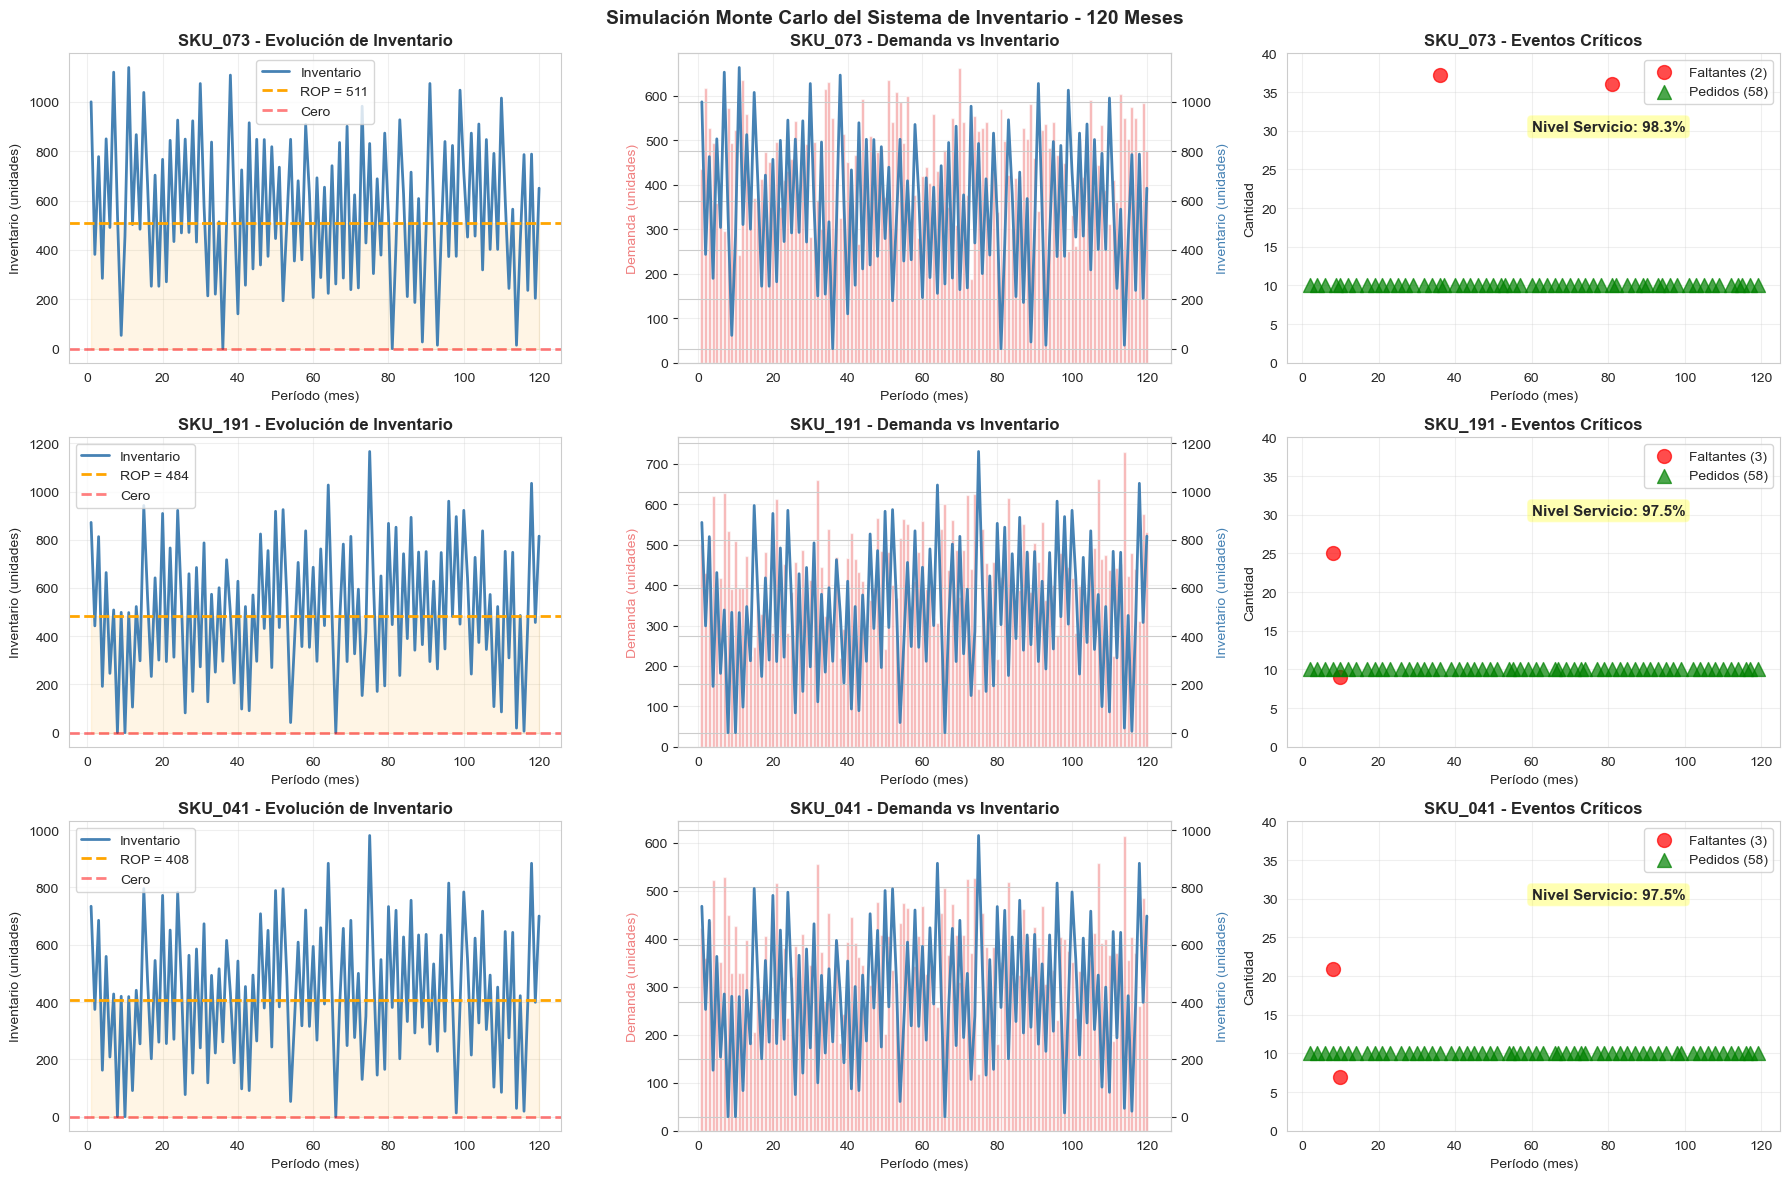

 Gráficas guardadas: 03_Simulacion_Dinamica.png


In [75]:
# ============================================================================
# 11. VISUALIZACIÓN DE RESULTADOS DE SIMULACIÓN
# ============================================================================

print("\n" + "="*80)
print("GRÁFICAS 4: DINÁMICAS DE SIMULACIÓN - 120 PERÍODOS")
print("="*80 + "\n")

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Simulación Monte Carlo del Sistema de Inventario - 120 Meses', 
             fontsize=14, fontweight='bold')

for idx, sku in enumerate(skus_seleccionados):
    df_sim = resultados_sim[sku]['df_simulacion']
    res = resultados_sim[sku]
    ROP = parametros_inventario[sku]['punto_reorden']
    EOQ = parametros_inventario[sku]['EOQ']
    
    # ===== Gráfica 1: Evolución de Inventario =====
    ax1 = axes[idx, 0]
    ax1.plot(df_sim['Periodo'], df_sim['Inventario_Despues'], linewidth=2, color='steelblue', label='Inventario')
    ax1.axhline(ROP, color='orange', linestyle='--', linewidth=2, label=f'ROP = {ROP:.0f}')
    ax1.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Cero')
    ax1.fill_between(df_sim['Periodo'], 0, ROP, alpha=0.1, color='orange')
    ax1.set_title(f'{sku} - Evolución de Inventario', fontweight='bold')
    ax1.set_xlabel('Período (mes)')
    ax1.set_ylabel('Inventario (unidades)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # ===== Gráfica 2: Demanda vs Inventario =====
    ax2 = axes[idx, 1]
    ax2_2 = ax2.twinx()
    
    l1 = ax2.bar(df_sim['Periodo'], df_sim['Demanda'], alpha=0.6, color='lightcoral', label='Demanda')
    l2 = ax2_2.plot(df_sim['Periodo'], df_sim['Inventario_Despues'], color='steelblue', linewidth=2, label='Inventario')
    
    ax2.set_title(f'{sku} - Demanda vs Inventario', fontweight='bold')
    ax2.set_xlabel('Período (mes)')
    ax2.set_ylabel('Demanda (unidades)', color='lightcoral')
    ax2_2.set_ylabel('Inventario (unidades)', color='steelblue')
    ax2.grid(True, alpha=0.3)
    
    # ===== Gráfica 3: Faltantes y Pedidos =====
    ax3 = axes[idx, 2]
    
    # Faltantes (usamos Hubo_Faltante para identificar períodos con faltantes)
    periodos_faltante = df_sim[df_sim['Hubo_Faltante'] == True]['Periodo']
    faltantes_valor = df_sim[df_sim['Hubo_Faltante'] == True]['Faltantes']
    ax3.scatter(periodos_faltante, faltantes_valor, color='red', s=100, alpha=0.7, 
               label=f'Faltantes ({len(periodos_faltante)})', zorder=3)
    
    # Pedidos (usamos Pedido_Realizado)
    periodos_pedidos = df_sim[df_sim['Pedido_Realizado'] == True]['Periodo']
    ax3.scatter(periodos_pedidos, [10]*len(periodos_pedidos), color='green', s=100, 
               marker='^', alpha=0.7, label=f'Pedidos ({len(periodos_pedidos)})', zorder=3)
    
    # Nivel de servicio como texto
    ax3.text(60, 30, f"Nivel Servicio: {res['nivel_servicio']:.1f}%", 
            fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3),
            fontweight='bold')
    
    ax3.set_title(f'{sku} - Eventos Críticos', fontweight='bold')
    ax3.set_xlabel('Período (mes)')
    ax3.set_ylabel('Cantidad')
    ax3.set_ylim(0, 40)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/yedisoncuervo/Desktop/Actividad_GestionCadenas/src/03_Simulacion_Dinamica.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(" Gráficas guardadas: 03_Simulacion_Dinamica.png")


ANÁLISIS COMPARATIVO - BENCHMARK ENTRE SKU

    SKU CV (%) Nivel Servicio Inv. Promedio Rotación Inv. Pedidos/Año
SKU_073  21.4%          98.3%           565         0.82x         6.0
SKU_191  26.0%          97.5%           504         0.88x         6.0
SKU_041  26.2%          97.5%           427         0.88x         6.0

GRÁFICA 5: COMPARATIVO VISUAL DE MÉTRICAS



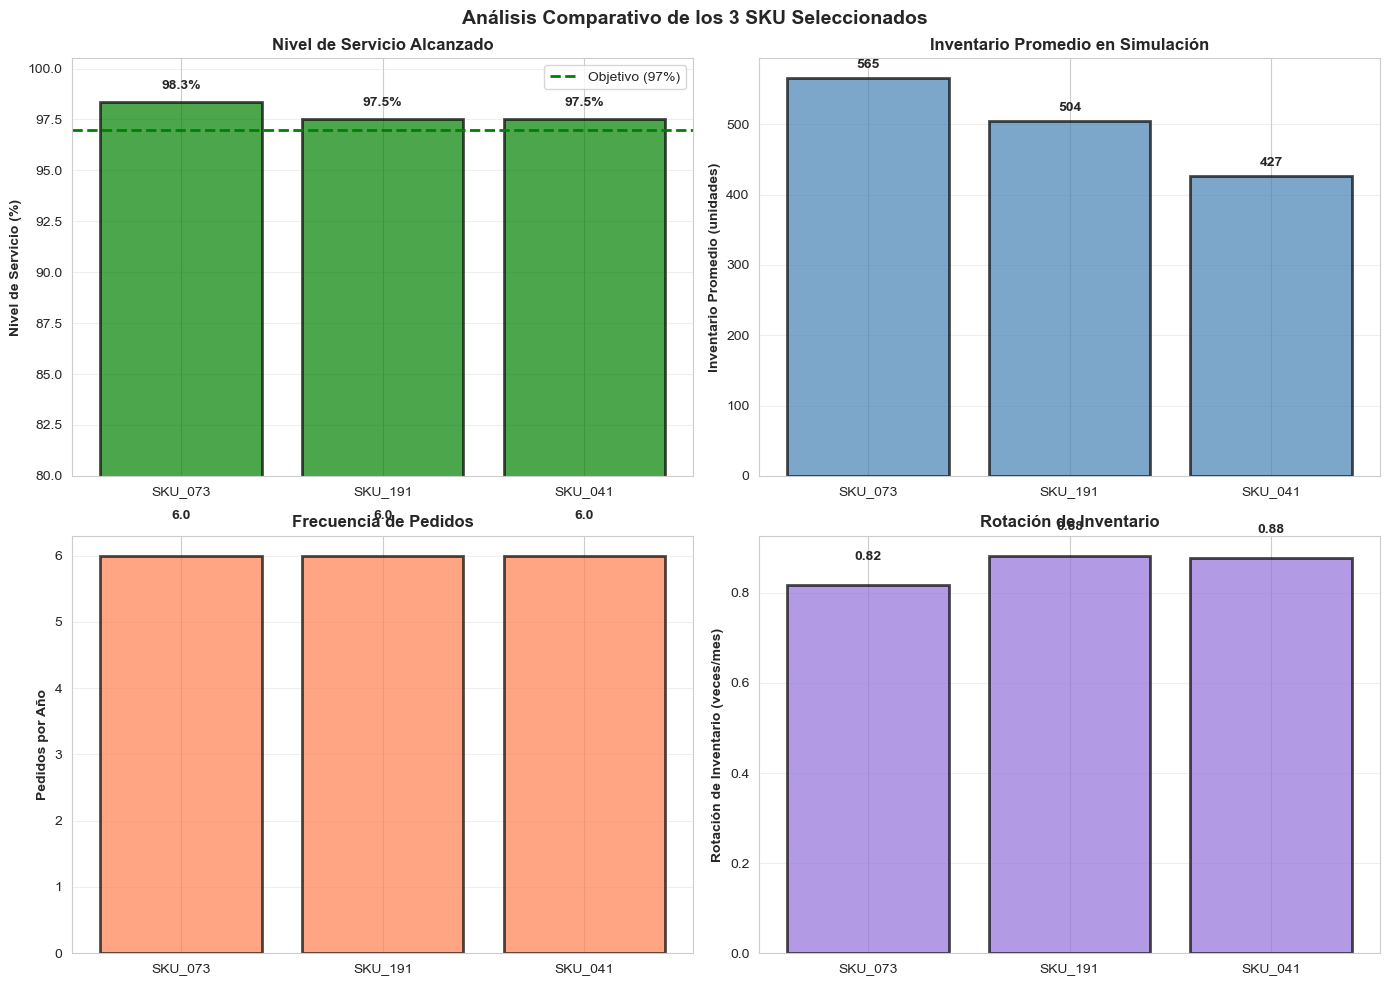

✅ Gráficas guardadas: 04_Comparativo_Metricas.png


In [ ]:
# ============================================================================
# 12. ANÁLISIS COMPARATIVO - BENCHMARKING DE LOS 3 SKU
# ============================================================================

print("\n" + "="*80)
print("ANÁLISIS COMPARATIVO - BENCHMARK ENTRE SKU")
print("="*80 + "\n")

# Tabla comparativa
tabla_comparativa = []
for sku in skus_seleccionados:
    res = resultados_sim[sku]
    p = parametros_inventario[sku]
    
    # Calcular desviación estándar desde los datos originales
    demanda_original = datos_seleccionados[sku]['demanda']
    desv_original = np.std(demanda_original, ddof=1)
    cv = (desv_original / p['demanda_mensual']) * 100
    
    # Eficiencia de inventario (demanda/inventario promedio)
    if res['inventario_promedio'] > 0:
        eficiencia_inv = p['demanda_mensual'] / res['inventario_promedio']
    else:
        eficiencia_inv = 0
    
    tabla_comparativa.append({
        'SKU': sku,
        'CV (%)': f"{cv:.1f}%",
        'Nivel Servicio': f"{res['nivel_servicio']:.1f}%",
        'Inv. Promedio': f"{res['inventario_promedio']:.0f}",
        'Rotación Inv.': f"{eficiencia_inv:.2f}x",
        'Pedidos/Año': f"{p['num_pedidos_anual']:.1f}"
    })

df_comparativa = pd.DataFrame(tabla_comparativa)
print(df_comparativa.to_string(index=False))

# Gráfica comparativa
print("\n" + "="*80)
print("GRÁFICA 5: COMPARATIVO VISUAL DE MÉTRICAS")
print("="*80 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Comparativo de los 3 SKU Seleccionados', fontsize=14, fontweight='bold')

# Extraer datos
skus_list = list(skus_seleccionados)
niveles_servicio = [resultados_sim[sku]['nivel_servicio'] for sku in skus_list]
inventarios = [resultados_sim[sku]['inventario_promedio'] for sku in skus_list]
pedidos = [parametros_inventario[sku]['num_pedidos_anual'] for sku in skus_list]

# Gráfica 1: Nivel de Servicio
ax1 = axes[0, 0]
colors1 = ['green' if x >= 97 else 'orange' if x >= 95 else 'red' for x in niveles_servicio]
bars1 = ax1.bar(skus_list, niveles_servicio, color=colors1, alpha=0.7, edgecolor='black', linewidth=2)
ax1.axhline(97, color='green', linestyle='--', linewidth=2, label='Objetivo (97%)')
ax1.set_ylabel('Nivel de Servicio (%)', fontweight='bold')
ax1.set_title('Nivel de Servicio Alcanzado', fontweight='bold')
ax1.set_ylim([80, 100.5])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
# Valores encima de las barras
for bar, val in zip(bars1, niveles_servicio):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Gráfica 2: Inventario Promedio
ax2 = axes[0, 1]
bars2 = ax2.bar(skus_list, inventarios, color='steelblue', alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Inventario Promedio (unidades)', fontweight='bold')
ax2.set_title('Inventario Promedio en Simulación', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, inventarios):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{val:.0f}', ha='center', va='bottom', fontweight='bold')

# Gráfica 3: Número de Pedidos por Año
ax3 = axes[1, 0]
bars3 = ax3.bar(skus_list, pedidos, color='coral', alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('Pedidos por Año', fontweight='bold')
ax3.set_title('Frecuencia de Pedidos', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, pedidos):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Gráfica 4: Rotación de Inventario
ax4 = axes[1, 1]
rotaciones = []
for sku in skus_list:
    res = resultados_sim[sku]
    p = parametros_inventario[sku]
    if res['inventario_promedio'] > 0:
        rotacion = p['demanda_mensual'] / res['inventario_promedio']
    else:
        rotacion = 0
    rotaciones.append(rotacion)

bars4 = ax4.bar(skus_list, rotaciones, color='mediumpurple', alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_ylabel('Rotación de Inventario (veces/mes)', fontweight='bold')
ax4.set_title('Rotación de Inventario', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, rotaciones):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/yedisoncuervo/Desktop/Actividad_GestionCadenas/src/04_Comparativo_Metricas.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(" Gráficas guardadas: 04_Comparativo_Metricas.png")